In [9]:
import json
import re
import math

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


from pathlib import Path
from collections import Counter, defaultdict
from scipy.sparse import csr_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from openTSNE import TSNE

# Part 1: Word Embeddings

In [10]:
TEXT_FILE = "init_data/cleaned.txt"
TOKENS_FILE = "init_data/tokens.json"
TOKENS_COUNT_FILE = "init_init_data/token_count.json"
TOP_10000_TOKENS_FILE = "init_data/top_10000_tokens.json"

with open(TEXT_FILE, "r", encoding="utf-8") as f:
    init_data = f.read()

with open(TOKENS_FILE, "r", encoding="utf-8") as f:
    all_tokens = json.load(f)

with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    top_10000_tokens_dict = json.load(f)

valid_vocabulary = set(top_10000_tokens_dict.keys())

processed_tokens = [token if token in valid_vocabulary else "<UNK>" for token in all_tokens]

with open("init_data/final_unk_tokens.json", "w", encoding="utf-8") as f:
    json.dump(processed_tokens, f, ensure_ascii=False, indent=4)

tokens = processed_tokens
tokens

['خاندانی',
 'اختلافات',
 'شادی',
 'کے',
 'لباس',
 'پر',
 'اعتراض',
 'اور',
 'بیوی',
 'کی',
 'مبینہ',
 'توہین',
 'پر',
 'والدین',
 'سے',
 'ناراضی',
 '۔',
 'یہ',
 'کسی',
 'پاکستانی',
 'یا',
 'انڈین',
 'ڈرامے',
 'کی',
 'کہانی',
 'نہیں',
 'بلکہ',
 'فٹبال',
 'کے',
 'مشہور',
 'کھلاڑی',
 'اور',
 'انگلینڈ',
 'کے',
 'سابق',
 'کپتان',
 'سر',
 'ڈیوڈ',
 'بیکہم',
 'اور',
 'وکٹوریہ',
 'بیکہم',
 'کے',
 'بیٹے',
 'بروکلن',
 'کے',
 'الزامات',
 'ہیں',
 'جو',
 'انھوں',
 'نے',
 'اپنے',
 'والدین',
 'پر',
 'عائد',
 'کیے',
 'ہیں',
 '۔',
 'پیر',
 'کی',
 'رات',
 'بروکلن',
 'بیکہم',
 'نے',
 'انسٹاگرام',
 'پر',
 'چھ',
 'صفحات',
 'پر',
 'مشتمل',
 'ایک',
 'طویل',
 'پوسٹ',
 'شیئر',
 'کی',
 'جس',
 'میں',
 'انھوں',
 'نے',
 'اپنے',
 'والدین',
 'سر',
 'ڈیوڈ',
 'بیکہم',
 'اور',
 'لیڈی',
 'وکٹوریہ',
 'بیکہم',
 'کے',
 'خلاف',
 'اپنے',
 'دل',
 'کی',
 'بھڑاس',
 'نکالی',
 'اور',
 'تفصیل',
 'سے',
 'اپنی',
 'شکایات',
 'بیان',
 'کیں',
 '۔',
 'اور',
 'یہ',
 'وہ',
 'لمحہ',
 'تھا',
 'جب',
 'بیکہم',
 'خاندان',
 'کے',
 'اندرونی',
 '

## TF-IDF and PMI Weighted Representations

### TF-IDF

In [11]:
CLEANED_FILE = Path("init_data/cleaned.txt")
TOP_10000_TOKENS_FILE = Path("init_data/top_10000_tokens.json")
TFIDF_OUTPUT_FILE = Path("embeddings/tfidf_matrix.npy")
TOPIC_REPORT_FILE = Path("init_data/top_10_discriminative_words_by_topic.json")

news_topics = [
    "Politics",
    "Elections",
    "Government Policy",
    "International Relations",
    "Diplomacy",
    "War and Conflict",
    "Defense",
    "National Security",
    "Crime",
    "Courts and Legal Affairs",
    "Human Rights",
    "Immigration",
    "Economy",
    "Stock Markets",
    "Banking",
    "Inflation",
    "Employment",
    "Real Estate",
    "Business",
    "Startups",
    "Technology",
    "Artificial Intelligence",
    "Cybersecurity",
    "Science",
    "Space Exploration",
    "Climate Change",
    "Environment",
    "Energy",
    "Oil and Gas",
    "Transportation",
    "Automotive",
    "Aviation",
    "Health",
    "Medicine",
    "Public Health",
    "Pandemics",
    "Education",
    "Universities",
    "Sports",
    "Football",
    "Cricket",
    "Basketball",
    "Tennis",
    "Entertainment",
    "Movies",
    "Television",
    "Music",
    "Celebrities",
    "Culture",
    "Lifestyle",
    "Fashion",
    "Food",
    "Travel",
    "Weather",
    "Natural Disasters",
    "Agriculture",
    "Religion",
    "Social Media",
    "Consumer Affairs",
    "Investigations",
    "Local News",
    "Breaking News",
    "Opinion",
    "Data Journalism",
]

with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    top_10000_tokens_dict = json.load(f)

base_vocab = list(top_10000_tokens_dict.keys())
if "<UNK>" not in base_vocab:
    base_vocab.append("<UNK>")

word2idx = {word: idx for idx, word in enumerate(base_vocab)}
idx2word = np.array(base_vocab)

# Split corpus into documents using markers in cleaned.txt.
with open(CLEANED_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

documents = []
current_doc_lines = []
doc_marker_pattern = re.compile(r"^\[\d+\]\s*$")

for raw_line in lines:
    line = raw_line.strip()
    if doc_marker_pattern.match(line):
        if current_doc_lines:
            documents.append(" ".join(current_doc_lines).strip())
            current_doc_lines = []
        continue
    if line:
        current_doc_lines.append(line)

if current_doc_lines:
    documents.append(" ".join(current_doc_lines).strip())

N = len(documents)
V = len(base_vocab)

tf_matrix = np.zeros((N, V), dtype=np.float32)

for doc_idx, doc in enumerate(documents):
    tokens = doc.split()
    for token in tokens:
        mapped_token = token if token in word2idx else "<UNK>"
        tf_matrix[doc_idx, word2idx[mapped_token]] += 1.0

# TF-IDF calculation
df = (tf_matrix > 0).sum(axis=0).astype(np.float32)
idf = np.log(N / (1.0 + df))
tfidf_matrix = tf_matrix * idf

TFIDF_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
np.save(TFIDF_OUTPUT_FILE, tfidf_matrix)

# ---------- Topic category discovery ----------
def kmeans_numpy(X, k=5, max_iter=40, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]

    initial_idx = rng.choice(n_samples, size=k, replace=False)
    centroids = X[initial_idx].copy()
    labels = np.zeros(n_samples, dtype=np.int32)

    for _ in range(max_iter):
        dists = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        new_labels = np.argmin(dists, axis=1)

        if np.array_equal(new_labels, labels):
            break
        labels = new_labels

        for cluster_id in range(k):
            members = X[labels == cluster_id]
            if len(members) == 0:
                centroids[cluster_id] = X[rng.integers(0, n_samples)]
            else:
                centroids[cluster_id] = members.mean(axis=0)

    return labels, centroids

# Normalization for clustering stability
doc_norms = np.linalg.norm(tfidf_matrix, axis=1, keepdims=True)
doc_norms[doc_norms == 0] = 1.0
X = tfidf_matrix / doc_norms

k_topics = min(len(news_topics), N)
cluster_labels, centroids = kmeans_numpy(X, k=k_topics, max_iter=50, random_state=42)

unk_idx = word2idx["<UNK>"]
top_words_per_topic = {}

for topic_id in range(k_topics):
    topic_name = news_topics[topic_id]
    topic_centroid = centroids[topic_id].copy()
    topic_centroid[unk_idx] = -np.inf
    top_indices = np.argsort(topic_centroid)[-10:][::-1]

    words = [idx2word[i] for i in top_indices]
    scores = [float(topic_centroid[i]) for i in top_indices]

    top_words_per_topic[topic_name] = {
        "num_documents": int((cluster_labels == topic_id).sum()),
        "top_10_words": words,
        "top_10_scores": scores,
    }

with open(TOPIC_REPORT_FILE, "w", encoding="utf-8") as f:
    json.dump(top_words_per_topic, f, ensure_ascii=False, indent=2)

for topic_name, topic_info in top_words_per_topic.items():
    print(f"{topic_name} (docs={topic_info['num_documents']}):")
    print(", ".join(topic_info["top_10_words"]))
    print()

Politics (docs=3):
رضوان, ریٹ, بلے, رن, مڈل, پہ, آرڈر, میچ, آؤٹ, ریٹائرڈ

Elections (docs=3):
مینی, انجینیئر, میت, مک, تابوت, سیشن, اشتیاق, اکیڈیمی, مرزا, راولپنڈی

Government Policy (docs=4):
ایران, اسرائیل, ڈرونز, یوکرین, مذاکرات, امریکہ, روس, میزائل, امریکی, جنگ

International Relations (docs=1):
ایمسٹرڈیم, اسرائیلی, مکابی, فٹبال, نیدرلینڈز, تل, ابیب, شائقین, کلب, مظاہرین

Diplomacy (docs=6):
سلطان, ایپسٹین, داعش, واردات, راہی, دکان, عزام, مشرف, بینک, سلیم

War and Conflict (docs=6):
بنگلہ, دیش, دیپو, آسام, انڈیا, سسٹرز, یونس, سیون, انتخابی, دلوں

Defense (docs=5):
ایپسٹین, انصاف, لقمان, ڈیلیوری, ٹیکساس, خان, امریکی, ٹکرا, ڈرون, ترانہ

National Security (docs=1):
چرچ, کورفیلڈ, استحصال, ایڈورڈ, جنسی, مائیکل, رابرٹ, شلٹز, ورکرز, کینیڈین

Crime (docs=1):
سان, ڈیاگو, سمتھ, بم, ایف, ملزم, فرانسسکو, گاڑی, فرمز, دھماکے

Courts and Legal Affairs (docs=13):
طالبان, افغانستان, افغان, ٹی, اقوام, متحدہ, پی, رپورٹ, القاعدہ, محسود

Human Rights (docs=5):
گلوان, فلم, ٹیزر, چین, گلوبل, وادی, ٹائمز,

### PMI

Co-occurrence matrix built: (10001, 10001)
Saved: embeddings\ppmi_matrix.npy
PPMI shape: (10001, 10001)


c:\Users\Muddassir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Muddassir\AppData\Local\Temp\ipykernel_39524\4053590383.py:196: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Muddassir\AppData\Local\Temp\ipykernel_39524\4053590383.py:196: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\Muddassir\AppData\Local\Temp\ipykernel_39524\4053590383.py:196: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



Top-5 nearest neighbours:

پاکستان : انڈیا (0.2016), کرکٹ (0.1822), کے (0.1686), میں (0.1643), کپ (0.1482)
انڈیا : بنگلہ (0.2019), پاکستان (0.2016), دیش (0.1890), کے (0.1604), میں (0.1565)
کرکٹ : بورڈ (0.2103), پاکستان (0.1822), کھیلنے (0.1659), کلب (0.1605), ٹوئنٹی (0.1534)
ایپسٹین : جیفری (0.3123), میلز (0.2780), ای (0.2671), سلیم (0.2474), احمدی (0.2385)
امریکہ : ایران (0.2048), امریکی (0.1735), قطر (0.1522), خطے (0.1428), جنگلی (0.1347)
ایران : اسرائیل (0.2107), امریکہ (0.2048), جوہری (0.1982), عراق (0.1954), سعودی (0.1803)
افغانستان : پکتیکا (0.1831), اوپننگ (0.1803), طالبان (0.1788), افغان (0.1576), انخلا (0.1521)
پولیس : افسران (0.2113), افسر (0.1950), کمشنر (0.1897), ملزم (0.1707), اسلم (0.1651)
فلم : دھورندھر (0.3063), بالی (0.2033), ٹریلر (0.1868), وڈ (0.1854), اکشے (0.1698)
حکومت : طالبان (0.3186), افغان (0.1895), قیادت (0.1635), صوبائی (0.1481), وزیر (0.1481)

Saved: init_data\ppmi_top5_neighbors.json


c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Matplotlib currently does not support Arabic natively.
  func(*args, **kwargs)
c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Muddassir\anaconda3\Lib\site-packages\IPython\core\pyl

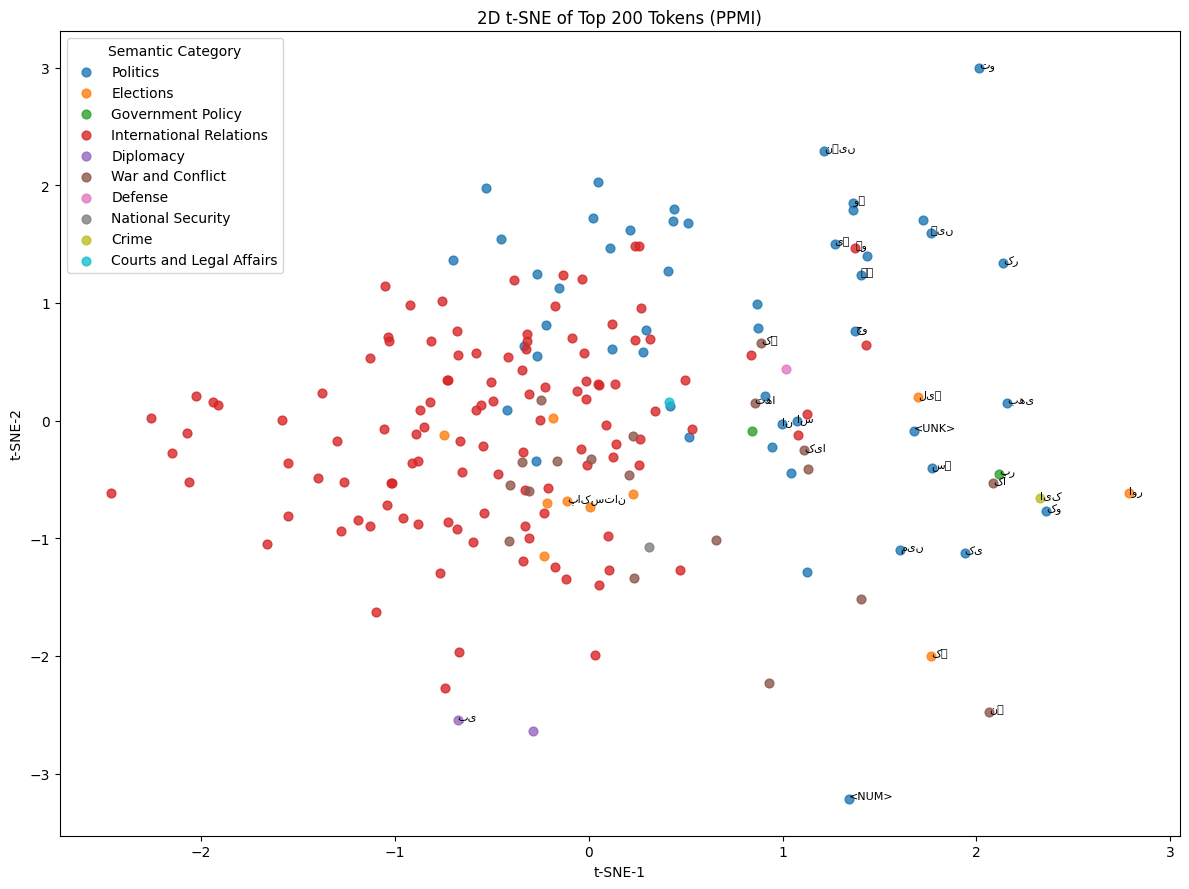

In [12]:
PPMI_OUTPUT_FILE = Path("embeddings/ppmi_matrix.npy")
TSNE_PLOT_FILE = Path("embeddings/tsne_top200_ppmi.png")
NEIGHBORS_FILE = Path("init_data/ppmi_top5_neighbors.json")

WINDOW_SIZE = 5
TOP_N_TSNE = 200
RANDOM_STATE = 42

with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    token_dict = json.load(f)

vocab = list(token_dict.keys())
if "<UNK>" not in vocab:
    vocab.append("<UNK>")

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = np.array(vocab)
V = len(vocab)

final_unk_path = Path("init_data/final_unk_tokens.json")
if final_unk_path.exists():
    with open(final_unk_path, "r", encoding="utf-8") as f:
        flat_tokens = json.load(f)
else:
    with open(TOKENS_FILE, "r", encoding="utf-8") as f:
        base_tokens = json.load(f)
    flat_tokens = [t if t in word2idx else "<UNK>" for t in base_tokens]

with open(CLEANED_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

doc_marker = re.compile(r"^\[\d+\]\s*$")
doc_lengths = []
current_len = 0

for raw in lines:
    line = raw.strip()
    if doc_marker.match(line):
        if current_len > 0:
            doc_lengths.append(current_len)
            current_len = 0
        continue
    if line:
        current_len += len(line.split())

if current_len > 0:
    doc_lengths.append(current_len)

expected = int(sum(doc_lengths))
if expected == len(flat_tokens):
    tokenized_docs = []
    pos = 0
    for length in doc_lengths:
        tokenized_docs.append(flat_tokens[pos:pos + length])
        pos += length
else:
    tokenized_docs = []
    current = []
    for raw in lines:
        line = raw.strip()
        if doc_marker.match(line):
            if current:
                tokenized_docs.append(current)
                current = []
            continue
        if line:
            for t in line.split():
                current.append(t if t in word2idx else "<UNK>")
    if current:
        tokenized_docs.append(current)

all_tokens = [t for doc in tokenized_docs for t in doc]

# Co-occurance matrix
cooc_counts = defaultdict(np.float32)

for toks in tokenized_docs:
    n = len(toks)
    for i in range(n):
        w1 = word2idx[toks[i]]
        left = max(0, i - WINDOW_SIZE)
        right = min(n, i + WINDOW_SIZE + 1)
        for j in range(left, right):
            if i == j:
                continue
            w2 = word2idx[toks[j]]
            cooc_counts[(w1, w2)] += 1.0

rows, cols, vals = [], [], []
for (r, c), v in cooc_counts.items():
    rows.append(r)
    cols.append(c)
    vals.append(float(v))

cooc = csr_matrix((np.array(vals, dtype=np.float64), (rows, cols)), shape=(V, V))
print("Co-occurrence matrix built:", cooc.shape)

# PPMI calculation
total = float(cooc.sum())
row_sum = np.asarray(cooc.sum(axis=1)).ravel()

coo = cooc.tocoo()
pmi_vals = np.zeros_like(coo.data, dtype=np.float64)

for k in range(len(coo.data)):
    i = coo.row[k]
    j = coo.col[k]
    cij = coo.data[k]
    p_ij = cij / total
    p_i = row_sum[i] / total
    p_j = row_sum[j] / total
    pmi = np.log2(p_ij / (p_i * p_j))
    if pmi > 0:
        pmi_vals[k] = pmi

mask = pmi_vals > 0
ppmi_sparse = csr_matrix(
    (pmi_vals[mask], (coo.row[mask], coo.col[mask])),
    shape=(V, V),
    dtype=np.float32,
 )

ppmi = ppmi_sparse.toarray().astype(np.float32)
PPMI_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
np.save(PPMI_OUTPUT_FILE, ppmi)
print("Saved:", PPMI_OUTPUT_FILE)
print("PPMI shape:", ppmi.shape)

# 2D t-SNE visualization 
freq = Counter(all_tokens)
candidate_tokens = [w for w, _ in freq.most_common(max(TOP_N_TSNE * 4, TOP_N_TSNE))]
candidate_indices = [word2idx[w] for w in candidate_tokens]
candidate_matrix = ppmi_sparse[candidate_indices, :]
candidate_nnz = candidate_matrix.getnnz(axis=1)

top_tokens = [w for w, nnz in zip(candidate_tokens, candidate_nnz) if nnz > 0][:TOP_N_TSNE]
if len(top_tokens) < TOP_N_TSNE:
    for w, _ in freq.most_common(TOP_N_TSNE):
        if w not in top_tokens:
            top_tokens.append(w)
        if len(top_tokens) == TOP_N_TSNE:
            break

top_indices = [word2idx[w] for w in top_tokens]
X = ppmi_sparse[top_indices, :]

svd_dim = min(50, X.shape[0] - 1, X.shape[1] - 1)
svd_dim = max(2, svd_dim)
X_reduced = TruncatedSVD(n_components=svd_dim, random_state=RANDOM_STATE).fit_transform(X)

# Normalize features to stabilize optimization
X_reduced = (X_reduced - X_reduced.mean(axis=0)) / (X_reduced.std(axis=0) + 1e-8)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(top_tokens) // 10)),
    metric="cosine",
    initialization="pca",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
X_2d = np.asarray(tsne.fit(X_reduced))

# Fallback if embedding collapses numerically
if (not np.isfinite(X_2d).all()) or np.std(X_2d[:, 0]) < 1e-8 or np.std(X_2d[:, 1]) < 1e-8:
    X_2d = X_reduced[:, :2].copy()

n_cats = min(10, len(news_topics), len(top_tokens))
kmeans = KMeans(n_clusters=n_cats, random_state=RANDOM_STATE, n_init=10)
cluster_ids = kmeans.fit_predict(X_reduced)
token_categories = [news_topics[cid] for cid in cluster_ids]
unique_cats = [news_topics[i] for i in range(n_cats)]

plt.figure(figsize=(12, 9))
cmap = plt.get_cmap("tab10")
cat_color = {cat: cmap(i % 10) for i, cat in enumerate(unique_cats)}

for cat in unique_cats:
    cat_mask = np.array([c == cat for c in token_categories])
    plt.scatter(
        X_2d[cat_mask, 0],
        X_2d[cat_mask, 1],
        s=40,
        alpha=0.8,
        label=cat,
        c=[cat_color[cat]],
    )

for i in range(min(30, len(top_tokens))):
    plt.annotate(top_tokens[i], (X_2d[i, 0], X_2d[i, 1]), fontsize=8)

plt.title("2D t-SNE of Top 200 Tokens (PPMI)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.legend(title="Semantic Category")
plt.tight_layout()

# TSNE_PLOT_FILE.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(TSNE_PLOT_FILE, dpi=200)
# plt.show()
# print("Saved:", TSNE_PLOT_FILE)

# Top 5 nearest neighbors 
def cosine(a, b):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

query_candidates = [
    "پاکستان", "انڈیا", "کرکٹ", "ایپسٹین", "امریکہ",
    "ایران", "افغانستان", "پولیس", "فلم", "حکومت",
    "طالبان", "چین",
]

queries = [q for q in query_candidates if q in word2idx]
if len(queries) < 10:
    for w, _ in freq.most_common(500):
        if w in word2idx and w != "<UNK>" and w not in queries:
            queries.append(w)
        if len(queries) >= 10:
            break
queries = queries[:10]

print("\nTop-5 nearest neighbours:\n")
neighbors_report = {}

for q in queries:
    q_idx = word2idx[q]
    q_vec = ppmi[q_idx]
    sims = []
    for i in range(V):
        if i == q_idx:
            continue
        score = cosine(q_vec, ppmi[i])
        sims.append((idx2word[i], score))
    sims.sort(key=lambda x: x[1], reverse=True)
    top5 = sims[:5]
    neighbors_report[q] = [{"word": w, "cosine": float(s)} for w, s in top5]
    print(q, ":", ", ".join([f"{w} ({s:.4f})" for w, s in top5]))

with open(NEIGHBORS_FILE, "w", encoding="utf-8") as f:
    json.dump(neighbors_report, f, ensure_ascii=False, indent=2)
print("\nSaved:", NEIGHBORS_FILE)

## Skip-gram Word2Vec

Device: cpu
Vocabulary size: 10001
Training pairs: 3,894,910
Epoch 1/5 | Step 200 | Loss 3.8721
Epoch 1/5 | Step 400 | Loss 3.3507
Epoch 1/5 | Step 600 | Loss 3.2645
Epoch 1/5 | Step 800 | Loss 3.2209
Epoch 1/5 | Step 1000 | Loss 3.2164
Epoch 1/5 | Step 1200 | Loss 3.1931
Epoch 1/5 | Step 1400 | Loss 3.1687
Epoch 1/5 | Step 1600 | Loss 3.1636
Epoch 1/5 | Step 1800 | Loss 3.1388
Epoch 1/5 | Step 2000 | Loss 3.1152
Epoch 1/5 | Step 2200 | Loss 3.1079
Epoch 1/5 | Step 2400 | Loss 3.1170
Epoch 1/5 | Step 2600 | Loss 3.0477
Epoch 1/5 | Step 2800 | Loss 3.1050
Epoch 1/5 | Step 3000 | Loss 3.0860
Epoch 1/5 | Step 3200 | Loss 3.0923
Epoch 1/5 | Step 3400 | Loss 3.0960
Epoch 1/5 | Step 3600 | Loss 2.9796
Epoch 1/5 | Step 3800 | Loss 3.0529
Epoch 1/5 completed | Average loss: 3.2824
Epoch 2/5 | Step 4000 | Loss 3.0437
Epoch 2/5 | Step 4200 | Loss 3.0327
Epoch 2/5 | Step 4400 | Loss 3.0003
Epoch 2/5 | Step 4600 | Loss 3.0043
Epoch 2/5 | Step 4800 | Loss 3.0262
Epoch 2/5 | Step 5000 | Loss 2.9930


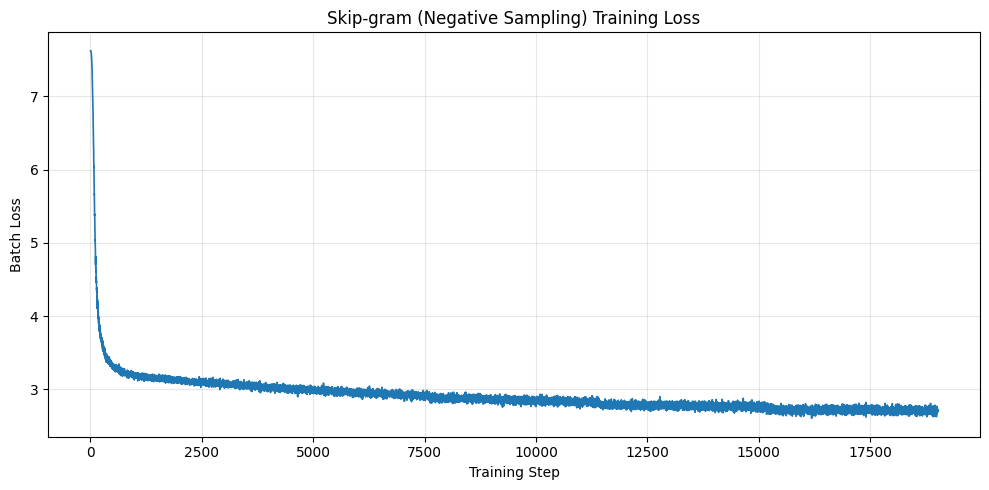

In [13]:

# hyperparameters: d=100, k=5, K=10, eta=0.001 (Adam)

EMB_DIM = 100
WINDOW_SIZE = 5
NUM_NEGATIVE = 10
LR = 0.001
BATCH_SIZE = 1024  # >= 512 (required)
EPOCHS = 5
LOG_INTERVAL = 200
SEED = 42

W2V_OUTPUT_FILE = Path("embeddings/embeddings_w2v.npy")
W2V_LOSS_PLOT_FILE = Path("embeddings/w2v_loss_curve.png")

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cpu")
print("Device:", device)

with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    token_dict = json.load(f)

vocab = list(token_dict.keys())
if "<UNK>" not in vocab:
    vocab.append("<UNK>")

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = np.array(vocab)
vocab_size = len(vocab)

final_unk_path = Path("init_data/final_unk_tokens.json")
if final_unk_path.exists():
    with open(final_unk_path, "r", encoding="utf-8") as f:
        flat_tokens = json.load(f)
else:
    with open(TOKENS_FILE, "r", encoding="utf-8") as f:
        base_tokens = json.load(f)
    flat_tokens = [t if t in word2idx else "<UNK>" for t in base_tokens]

with open(CLEANED_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

doc_marker = re.compile(r"^\[\d+\]\s*$")
doc_lengths = []
current_len = 0

for raw in lines:
    line = raw.strip()
    if doc_marker.match(line):
        if current_len > 0:
            doc_lengths.append(current_len)
            current_len = 0
        continue
    if line:
        current_len += len(line.split())

if current_len > 0:
    doc_lengths.append(current_len)

expected = int(sum(doc_lengths))
if expected == len(flat_tokens):
    tokenized_docs = []
    pos = 0
    for length in doc_lengths:
        tokenized_docs.append(flat_tokens[pos:pos + length])
        pos += length
else:
    tokenized_docs = []
    current = []
    for raw in lines:
        line = raw.strip()
        if doc_marker.match(line):
            if current:
                tokenized_docs.append(current)
                current = []
            continue
        if line:
            for t in line.split():
                current.append(t if t in word2idx else "<UNK>")
    if current:
        tokenized_docs.append(current)

# Build positive (center, context) training pairs with k=5
centers = []
contexts = []

for toks in tokenized_docs:
    idxs = [word2idx[t] for t in toks]
    n = len(idxs)
    for i, c in enumerate(idxs):
        left = max(0, i - WINDOW_SIZE)
        right = min(n, i + WINDOW_SIZE + 1)
        for j in range(left, right):
            if i == j:
                continue
            centers.append(c)
            contexts.append(idxs[j])

centers = np.asarray(centers, dtype=np.int64)
contexts = np.asarray(contexts, dtype=np.int64)
num_pairs = len(centers)
print(f"Vocabulary size: {vocab_size}")
print(f"Training pairs: {num_pairs:,}")

# Noise distribution Pn(w) 
token_counts = np.zeros(vocab_size, dtype=np.float64)
for t in flat_tokens:
    token_counts[word2idx[t]] += 1.0

noise_dist = np.power(token_counts, 0.75)
noise_dist = noise_dist / noise_dist.sum()
noise_dist_t = torch.tensor(noise_dist, dtype=torch.float32, device=device)

# Model with separate center/context embedding matrices V and U
class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        # V: center embeddings
        self.V = nn.Embedding(vocab_size, emb_dim)
        # U: context embeddings
        self.U = nn.Embedding(vocab_size, emb_dim)

        nn.init.uniform_(self.V.weight, -0.5 / emb_dim, 0.5 / emb_dim)
        nn.init.zeros_(self.U.weight)

    def forward(self, center_idx, pos_context_idx, neg_context_idx):
        v_c = self.V(center_idx)                     # [B, d]
        u_o = self.U(pos_context_idx)                # [B, d]
        u_k = self.U(neg_context_idx)                # [B, K, d]

        pos_logits = torch.sum(v_c * u_o, dim=1)     # [B]
        neg_logits = torch.bmm(u_k, v_c.unsqueeze(2)).squeeze(2)  # [B, K]

        # L = -log sigma(u_o^T v_c) - sum_k log sigma(-u_wk^T v_c)
        pos_loss = -F.logsigmoid(pos_logits).mean()
        neg_loss = -F.logsigmoid(-neg_logits).sum(dim=1).mean()
        return pos_loss + neg_loss

model = SkipGramNS(vocab_size=vocab_size, emb_dim=EMB_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# =====================================================
# Training loop
# =====================================================
steps_per_epoch = math.ceil(num_pairs / BATCH_SIZE)
global_step = 0
loss_history = []
step_history = []

for epoch in range(1, EPOCHS + 1):
    perm = np.random.permutation(num_pairs)
    centers_shuffled = centers[perm]
    contexts_shuffled = contexts[perm]

    epoch_loss_sum = 0.0

    for start in range(0, num_pairs, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_pairs)
        bsz = end - start

        c_batch = torch.tensor(centers_shuffled[start:end], dtype=torch.long, device=device)
        o_batch = torch.tensor(contexts_shuffled[start:end], dtype=torch.long, device=device)

        neg_flat = torch.multinomial(noise_dist_t, bsz * NUM_NEGATIVE, replacement=True)
        neg_batch = neg_flat.view(bsz, NUM_NEGATIVE)

        optimizer.zero_grad()
        loss = model(c_batch, o_batch, neg_batch)
        loss.backward()
        optimizer.step()

        loss_val = float(loss.item())
        epoch_loss_sum += loss_val * bsz

        global_step += 1
        loss_history.append(loss_val)
        step_history.append(global_step)

        if global_step % LOG_INTERVAL == 0:
            print(f"Epoch {epoch}/{EPOCHS} | Step {global_step} | Loss {loss_val:.4f}")

    epoch_avg_loss = epoch_loss_sum / num_pairs
    print(f"Epoch {epoch}/{EPOCHS} completed | Average loss: {epoch_avg_loss:.4f}")

# Save final averaged embeddings:
V_final = model.V.weight.detach().cpu().numpy()
U_final = model.U.weight.detach().cpu().numpy()
emb_final = 0.5 * (V_final + U_final)

W2V_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
np.save(W2V_OUTPUT_FILE, emb_final.astype(np.float32))
print(f"Saved embeddings to: {W2V_OUTPUT_FILE}")
print(f"Embeddings shape: {emb_final.shape}")

# Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(step_history, loss_history, linewidth=1.2)
plt.title("Skip-gram (Negative Sampling) Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Batch Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig(W2V_LOSS_PLOT_FILE, dpi=180)
plt.show()
# print(f"Saved loss curve to: {W2V_LOSS_PLOT_FILE}")

## Evaluation

### Nearest Neighbour and Analogy

In [17]:
with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    _tok_dict = json.load(f)

_vocab = list(_tok_dict.keys())
if "<UNK>" not in _vocab:
    _vocab.append("<UNK>")

word2idx = {w: i for i, w in enumerate(_vocab)}
idx2word = np.array(_vocab)

_w2v_path = Path("embeddings/embeddings_w2v.npy")
emb = np.load(_w2v_path).astype(np.float32)

def _normalize_rows(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n[n == 0] = 1.0
    return x / n

emb_norm = _normalize_rows(emb)

def topk_neighbors(query_word, k=10):
    if query_word not in word2idx:
        return []
    q_idx = word2idx[query_word]
    sims = emb_norm @ emb_norm[q_idx]
    sims[q_idx] = -1.0
    top_idx = np.argsort(sims)[-k:][::-1]
    return [(idx2word[i], float(sims[i])) for i in top_idx]

query_words = ["پاکستان", "حکومت", "عدالت", "معیشت", "فوج", "صحت", "تعلیم", "آبادی"]

print("Top-10 nearest neighbours (Skip-gram cleaned embeddings):\n")
for q in query_words:
    nbrs = topk_neighbors(q, k=10)
    if not nbrs:
        print(f"{q}: [not found in vocabulary]")
    else:
        print(f"{q}: " + ", ".join([f"{w} ({s:.4f})" for w, s in nbrs]))

# Keep for later cells
analysis_query_words = query_words

Top-10 nearest neighbours (Skip-gram cleaned embeddings):

پاکستان: ہورہے (0.6155), ایکسپیٹس (0.6111), مستفید (0.5985), ہمدردانہ (0.5773), زیرانتظام (0.5767), بائیکاٹ (0.5693), رنر (0.5642), میزبانی (0.5497), انڈیز (0.5492), میرپور (0.5484)
حکومت: عبوری (0.7738), طالبان (0.7604), افغان (0.6699), خانوں (0.6528), قیادت (0.6398), اخوندزادہ (0.6356), ہبت (0.6210), وفاقی (0.6164), اسٹیبلشمنٹ (0.6126), بالمعروف (0.6104)
عدالت: جع (0.7641), عدالتی (0.7503), استدعا (0.6981), دائر (0.6892), اڈیالہ (0.6878), امتناع (0.6876), کروایا (0.6746), سپرمیکس (0.6746), جرح (0.6712), مؤکل (0.6533)
معیشت: عکاسی (0.7010), امان (0.6885), رسوخ (0.6691), جانچا (0.6666), جماعتیں (0.6621), سرگرم (0.6603), مشقیں (0.6547), بمباری (0.6536), سینسرز (0.6450), پھیلاؤ (0.6448)
فوج: وینیزویلا (0.6386), اسرائیلی (0.6260), امریکی (0.6137), دستے (0.5754), مارولی (0.5677), فورسز (0.5664), کلرک (0.5594), سیمانجنتک (0.5558), بکملا (0.5533), پزشکیان (0.5498)
صحت: تولیدی (0.7949), پاؤلا (0.7619), مند (0.7173), یاب (0.6964), بشری

In [18]:
def analogy_top3(a, b, c):
    missing = [w for w in [a, b, c] if w not in word2idx]
    if missing:
        return [], missing

    vec = emb_norm[word2idx[b]] - emb_norm[word2idx[a]] + emb_norm[word2idx[c]]
    n = np.linalg.norm(vec)
    if n == 0:
        return [], []
    vec = vec / n

    sims = emb_norm @ vec
    sims[word2idx[a]] = -1.0
    sims[word2idx[b]] = -1.0
    sims[word2idx[c]] = -1.0

    top_idx = np.argsort(sims)[-3:][::-1]
    return [(idx2word[i], float(sims[i])) for i in top_idx], []

analogy_tests = [
    ("پاکستان", "لاہور", "انڈیا", "دہلی"),
    ("انڈیا", "دہلی", "پاکستان", "لاہور"),
    ("حکومت", "وزیر", "عدالت", "جج"),
    ("عدالت", "جج", "حکومت", "وزیر"),
    ("معیشت", "بینک", "تعلیم", "یونیورسٹی"),
    ("فوج", "دفاع", "پولیس", "جرم"),
    ("صحت", "ہسپتال", "تعلیم", "اسکول"),
    ("کرکٹ", "میچ", "فلم", "ڈراما"),
    ("امریکہ", "امریکی", "پاکستان", "پاکستانی"),
    ("چین", "بیجنگ", "پاکستان", "اسلام"),
]

print("Analogy tests (top-3 candidates):\n")
analogy_correct = 0
analogy_valid = 0

for a, b, c, expected in analogy_tests:
    top3, missing = analogy_top3(a, b, c)
    if missing:
        print(f"{a}:{b}::{c}:? -> skipped (missing: {missing})")
        continue

    analogy_valid += 1
    preds = [w for w, _ in top3]
    is_correct = expected in preds
    if is_correct:
        analogy_correct += 1

    print(f"{a}:{b}::{c}:? | expected={expected} | top3=" + ", ".join([f"{w} ({s:.4f})" for w, s in top3]) + f" | correct={is_correct}")

print(f"\nCorrect analogies in top-3: {analogy_correct}/{analogy_valid}")

Analogy tests (top-3 candidates):

پاکستان:لاہور::انڈیا:? | expected=دہلی | top3=قلندرز (0.6503), ہائیکورٹ (0.5909), کیلکو (0.5607) | correct=False
انڈیا:دہلی::پاکستان:? | expected=لاہور | top3=جمال (0.5724), نگلی (0.5694), انفو (0.5643) | correct=False
حکومت:وزیر::عدالت:? | expected=جج | top3=صفدر (0.5994), کروایا (0.5793), پیرو (0.5792) | correct=False
عدالت:جج::حکومت:? | expected=وزیر | top3=عبوری (0.6132), آن (0.4584), واجپائی (0.4486) | correct=False
معیشت:بینک::تعلیم:? | expected=یونیورسٹی | top3=آدھے (0.5960), دکان (0.5840), بینکر (0.5743) | correct=False
فوج:دفاع::پولیس:? | expected=جرم | top3=نمیش (0.5178), تلنگانہ (0.5046), موقع (0.5042) | correct=False
صحت:ہسپتال::تعلیم:? | expected=اسکول | top3=تھانہ (0.7065), اورنگی (0.6780), احاطے (0.6745) | correct=False
کرکٹ:میچ::فلم:? | expected=ڈراما | top3=دھورندھر (0.6596), اتا (0.6540), لپتا (0.6059) | correct=False
امریکہ:امریکی::پاکستان:? | expected=پاکستانی | top3=خلائی (0.5260), ڈار (0.5130), نائب (0.4846) | correct=False
چین:ب

The embeddings show partial semantic structure. Nearest neighbours are almost sensible, but analogy consistency is somewhat ok but not what we were looking for.


### Four Condition Comparison

In [37]:
# Set up foor comparison

_RAW = Path("init_data/raw.txt")
_C1_PATH = Path("embeddings/ppmi_matrix.npy")
_C2_PATH = Path("embeddings/embeddings_w2v_raw.npy")
_C3_PATH = Path("embeddings/embeddings_w2v.npy")
_C4_PATH = Path("embeddings/embeddings_w2v_d200.npy")
_C4_LOSS_PLOT = Path("embeddings/w2v_clean_d200_loss_curve.png")

comparison_query_words = ["پاکستان", "حکومت", "عدالت", "معیشت", "فوج"]
manual_pairs_20 = [
    ("پاکستان", "انڈیا"), ("پاکستان", "لاہور"), ("پاکستان", "اسلام"), ("حکومت", "وزیر"),
    ("حکومت", "قانون"), ("عدالت", "قانون"), ("عدالت", "مقدمہ"), ("معیشت", "بینک"),
    ("معیشت", "ڈالر"), ("فوج", "دفاع"), ("فوج", "جنگ"), ("صحت", "ہسپتال"),
    ("تعلیم", "یونیورسٹی"), ("کرکٹ", "میچ"), ("فلم", "ڈراما"), ("پولیس", "جرم"),
    ("افغانستان", "طالبان"), ("امریکہ", "ایران"), ("انڈیا", "چین"), ("روس", "امریکہ"),
]

with open(TOP_10000_TOKENS_FILE, "r", encoding="utf-8") as f:
    _tok_dict = json.load(f)
_vocab = list(_tok_dict.keys())
if "<UNK>" not in _vocab:
    _vocab.append("<UNK>")

word2idx_eval = {w: i for i, w in enumerate(_vocab)}
idx2word_eval = np.array(_vocab)
V_eval = len(_vocab)

def _normalize_rows(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n[n == 0] = 1.0
    return x / n

def _topk_neighbors(query_word, emb_norm, k=5):
    if query_word not in word2idx_eval:
        return []
    q_idx = word2idx_eval[query_word]
    sims = emb_norm @ emb_norm[q_idx]
    sims[q_idx] = -1.0
    top_idx = np.argsort(sims)[-k:][::-1]
    return [(idx2word_eval[i], float(sims[i])) for i in top_idx]

def _reciprocal_rank(query, target, emb_norm):
    if query not in word2idx_eval or target not in word2idx_eval:
        return None
    q_idx = word2idx_eval[query]
    t_idx = word2idx_eval[target]
    sims = emb_norm @ emb_norm[q_idx]
    sims[q_idx] = -1.0
    order = np.argsort(sims)[::-1]
    rank = int(np.where(order == t_idx)[0][0]) + 1
    return 1.0 / rank

def _compute_mrr(pairs, emb_norm):
    rrs = []
    used = []
    for q, t in pairs:
        rr = _reciprocal_rank(q, t, emb_norm)
        if rr is not None:
            rrs.append(rr)
            used.append((q, t))
    return (float(np.mean(rrs)) if rrs else 0.0), used

# Skip-gram trainer for C4 (d=200) if missing.
def _tokenize_marked_docs(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    doc_marker = re.compile(r"^\[\d+\]\s*$")
    docs = []
    current = []
    for raw in lines:
        line = raw.strip()
        if doc_marker.match(line):
            if current:
                docs.append(current)
                current = []
            continue
        if line:
            for t in line.split():
                current.append(t if t in word2idx_eval else "<UNK>")
    if current:
        docs.append(current)
    return docs

def _build_pairs(tokenized_docs, window=5):
    centers, contexts = [], []
    for toks in tokenized_docs:
        idxs = [word2idx_eval[t] for t in toks]
        n = len(idxs)
        for i, c in enumerate(idxs):
            left = max(0, i - window)
            right = min(n, i + window + 1)
            for j in range(left, right):
                if i == j:
                    continue
                centers.append(c)
                contexts.append(idxs[j])
    return np.asarray(centers, dtype=np.int64), np.asarray(contexts, dtype=np.int64)

def _noise_dist(tokenized_docs):
    counts = np.zeros(V_eval, dtype=np.float64)
    for doc in tokenized_docs:
        for t in doc:
            counts[word2idx_eval[t]] += 1.0
    dist = np.power(counts, 0.75)
    s = dist.sum()
    if s == 0:
        dist[:] = 1.0 / V_eval
    else:
        dist /= s
    return dist

class _SkipGramNS(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.V = nn.Embedding(vocab_size, emb_dim)
        self.U = nn.Embedding(vocab_size, emb_dim)
        nn.init.uniform_(self.V.weight, -0.5 / emb_dim, 0.5 / emb_dim)
        nn.init.zeros_(self.U.weight)

    def forward(self, c_idx, o_idx, neg_idx):
        v_c = self.V(c_idx)
        u_o = self.U(o_idx)
        u_k = self.U(neg_idx)
        pos_logits = torch.sum(v_c * u_o, dim=1)
        neg_logits = torch.bmm(u_k, v_c.unsqueeze(2)).squeeze(2)
        pos_loss = -F.logsigmoid(pos_logits).mean()
        neg_loss = -F.logsigmoid(-neg_logits).sum(dim=1).mean()
        return pos_loss + neg_loss

def _train_skipgram_d200_on_cleaned():
    device = torch.device("cpu")
    torch.manual_seed(42)
    np.random.seed(42)

    docs = _tokenize_marked_docs(CLEANED_FILE)
    centers, contexts = _build_pairs(docs, window=5)
    n_pairs = len(centers)
    print(f"C4 training pairs: {n_pairs:,}")

    dist = _noise_dist(docs)
    dist_t = torch.tensor(dist, dtype=torch.float32, device=device)

    model = _SkipGramNS(V_eval, 200).to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)

    BATCH = 1024
    EPOCHS = 5
    K = 10
    LOG_INT = 300
    losses = []
    steps = []
    gs = 0

    for ep in range(1, EPOCHS + 1):
        perm = np.random.permutation(n_pairs)
        c_sh = centers[perm]
        o_sh = contexts[perm]
        ep_sum = 0.0

        for st in range(0, n_pairs, BATCH):
            en = min(st + BATCH, n_pairs)
            bsz = en - st

            c_batch = torch.tensor(c_sh[st:en], dtype=torch.long, device=device)
            o_batch = torch.tensor(o_sh[st:en], dtype=torch.long, device=device)
            neg_flat = torch.multinomial(dist_t, bsz * K, replacement=True)
            neg_batch = neg_flat.view(bsz, K)

            opt.zero_grad()
            loss = model(c_batch, o_batch, neg_batch)
            loss.backward()
            opt.step()

            lv = float(loss.item())
            ep_sum += lv * bsz
            gs += 1
            losses.append(lv)
            steps.append(gs)
            if gs % LOG_INT == 0:
                print(f"C4 Epoch {ep}/{EPOCHS} | Step {gs} | Loss {lv:.4f}")

        print(f"C4 Epoch {ep}/{EPOCHS} avg loss: {ep_sum / n_pairs:.4f}")

    V_fin = model.V.weight.detach().cpu().numpy()
    U_fin = model.U.weight.detach().cpu().numpy()
    emb = 0.5 * (V_fin + U_fin)
    np.save(_C4_PATH, emb.astype(np.float32))

    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, linewidth=1.1)
    plt.title("C4 Skip-gram (d=200) on cleaned.txt Loss")
    plt.xlabel("Training Step")
    plt.ylabel("Batch Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(_C4_LOSS_PLOT, dpi=180)
    plt.show()

    return emb.astype(np.float32)

# shared result registry
if "condition_results" not in globals():
    condition_results = {}

print("Shared setup complete. Run C1-C4 cells below.")

Shared setup complete. Run C1-C4 cells below.


In [38]:
# C1: PPMI baseline (top-5 neighbours for 5 queries + MRR on 20 labelled pairs)

C1 = np.load(_C1_PATH).astype(np.float32)
C1n = _normalize_rows(C1)

print("C1 PPMI baseline")
print("-" * 20)
for q in comparison_query_words:
    nbrs = _topk_neighbors(q, C1n, k=5)
    print(f"{q}: " + ", ".join([f"{w} ({s:.4f})" for w, s in nbrs]))

mrr_c1, used_c1 = _compute_mrr(manual_pairs_20, C1n)
print(f"MRR ({len(used_c1)} pairs): {mrr_c1:.4f}")

condition_results["C1 PPMI baseline"] = mrr_c1

C1 PPMI baseline
--------------------
پاکستان: انڈیا (0.2016), کرکٹ (0.1822), کے (0.1686), میں (0.1643), کپ (0.1482)
حکومت: طالبان (0.3186), افغان (0.1895), قیادت (0.1635), صوبائی (0.1481), وزیر (0.1481)
عدالت: کورٹ (0.2603), مجسٹریٹ (0.1981), درخواست (0.1967), جسٹس (0.1933), سزا (0.1690)
معیشت: اشتراک (0.1939), بسواجیت (0.1937), دیکھیے (0.1787), بگڑتی (0.1643), ملکی (0.1467)
فوج: بکملا (0.1973), سنتوش (0.1939), کلرک (0.1549), مارولی (0.1539), سیمانجنتک (0.1539)
MRR (19 pairs): 0.1478


In [39]:
# C2: Skip-gram on raw.txt (top-5 neighbours for 5 queries + MRR on 20 labelled pairs)

if _C2_PATH.exists():
    C2 = np.load(_C2_PATH).astype(np.float32)
    print("Loaded C2 embedding from disk")
else:
    raise FileNotFoundError("C2 embedding missing. Please train raw skip-gram first.")

C2n = _normalize_rows(C2)

print("C2 Skip-gram on raw.txt")
print("-" * 24)
for q in comparison_query_words:
    nbrs = _topk_neighbors(q, C2n, k=5)
    print(f"{q}: " + ", ".join([f"{w} ({s:.4f})" for w, s in nbrs]))

mrr_c2, used_c2 = _compute_mrr(manual_pairs_20, C2n)
print(f"MRR ({len(used_c2)} pairs): {mrr_c2:.4f}")

condition_results["C2 Skip-gram raw.txt"] = mrr_c2

Loaded C2 embedding from disk
C2 Skip-gram on raw.txt
------------------------
پاکستان: رنر (0.6470), ہورہے (0.6248), مستفید (0.5905), بائیکاٹ (0.5862), می (0.5814)
حکومت: عبوری (0.7761), طالبان (0.7717), خانوں (0.6622), وفاقی (0.6528), قیادت (0.6523)
عدالت: جع (0.7489), اڈیالہ (0.7107), استدعا (0.6936), امتناع (0.6883), دائر (0.6786)
معیشت: سرگرم (0.7159), پھیلاؤ (0.6740), بمباری (0.6647), جانچا (0.6486), انفراسٹرکچر (0.6435)
فوج: کمانڈو (0.7341), اسرائیلی (0.6739), کلرک (0.6230), بکملا (0.6196), وینیزویلا (0.6180)
MRR (19 pairs): 0.0890


In [40]:
# C3: Skip-gram on cleaned.txt (top-5 neighbours for 5 queries + MRR on 20 labelled pairs)

C3 = np.load(_C3_PATH).astype(np.float32)
C3n = _normalize_rows(C3)

print("C3 Skip-gram on cleaned.txt")
print("-" * 28)
for q in comparison_query_words:
    nbrs = _topk_neighbors(q, C3n, k=5)
    print(f"{q}: " + ", ".join([f"{w} ({s:.4f})" for w, s in nbrs]))

mrr_c3, used_c3 = _compute_mrr(manual_pairs_20, C3n)
print(f"MRR ({len(used_c3)} pairs): {mrr_c3:.4f}")

condition_results["C3 Skip-gram cleaned.txt"] = mrr_c3

C3 Skip-gram on cleaned.txt
----------------------------
پاکستان: ہورہے (0.6155), ایکسپیٹس (0.6111), مستفید (0.5985), ہمدردانہ (0.5773), زیرانتظام (0.5767)
حکومت: عبوری (0.7738), طالبان (0.7604), افغان (0.6699), خانوں (0.6528), قیادت (0.6398)
عدالت: جع (0.7641), عدالتی (0.7503), استدعا (0.6981), دائر (0.6892), اڈیالہ (0.6878)
معیشت: عکاسی (0.7010), امان (0.6885), رسوخ (0.6691), جانچا (0.6666), جماعتیں (0.6621)
فوج: وینیزویلا (0.6386), اسرائیلی (0.6260), امریکی (0.6137), دستے (0.5754), مارولی (0.5677)
MRR (19 pairs): 0.0995


In [41]:
# C4: Skip-gram on cleaned.txt with d=200 (top-5 neighbours for 5 queries + MRR on 20 labelled pairs)

if _C4_PATH.exists():
    C4 = np.load(_C4_PATH).astype(np.float32)
    print("Loaded C4 embedding from disk")
else:
    print("C4 embedding not found. Training d=200 model now...")
    C4 = _train_skipgram_d200_on_cleaned()

C4n = _normalize_rows(C4)

print("C4 Skip-gram cleaned.txt d=200")
print("-" * 32)
for q in comparison_query_words:
    nbrs = _topk_neighbors(q, C4n, k=5)
    print(f"{q}: " + ", ".join([f"{w} ({s:.4f})" for w, s in nbrs]))

mrr_c4, used_c4 = _compute_mrr(manual_pairs_20, C4n)
print(f"MRR ({len(used_c4)} pairs): {mrr_c4:.4f}")

condition_results["C4 Skip-gram cleaned.txt d=200"] = mrr_c4

Loaded C4 embedding from disk
C4 Skip-gram cleaned.txt d=200
--------------------------------
پاکستان: ہمدردانہ (0.5533), ایکسپیٹس (0.5473), رنر (0.5421), ہورہے (0.5360), مستفید (0.5169)
حکومت: طالبان (0.6957), عبوری (0.6869), خانوں (0.6086), وفاقی (0.5983), اخوندزادہ (0.5919)
عدالت: جع (0.6728), سنائے (0.6506), مؤکل (0.6381), دائر (0.6380), جرح (0.6296)
معیشت: عکاسی (0.6300), پھیلاؤ (0.6178), سرگرم (0.6168), بمباری (0.6135), جانچا (0.5937)
فوج: وینیزویلا (0.5854), بکملا (0.5765), سیمانجنتک (0.5592), مارولی (0.5494), کرنل (0.5296)
MRR (19 pairs): 0.0310


In [43]:
# Final comparison discussion (best condition + effect of increasing d)

print("MRR Summary:")
for name, val in condition_results.items():
    print(f"{name}: {val:.4f}")

best_name, best_mrr = max(condition_results.items(), key=lambda x: x[1])
print(f"\nBest condition: {best_name} (MRR={best_mrr:.4f})")

MRR Summary:
C1 PPMI baseline: 0.1478
C2 Skip-gram raw.txt: 0.0890
C3 Skip-gram cleaned.txt: 0.0995
C4 Skip-gram cleaned.txt d=200: 0.0310

Best condition: C1 PPMI baseline (MRR=0.1478)


Increasing d from 100 to 200 does not help here, d=100 is more effective/efficient.

# Part 2: Sequence Labeling